# ðŸ”® Notebook 11: Scenario Planning â€” What-If Budget Simulations

**The real value of MMM isn't just measuring past performance â€” it's predicting what happens under different budget scenarios.** Once you have a fitted model with posterior samples of coefficients, decay rates, and saturation parameters, you can simulate *any* hypothetical budget allocation and get a revenue prediction with uncertainty.

This notebook fits a **real PyMC-Marketing MMM** on weekly data, then uses the model's prediction API to evaluate four common what-if scenarios:

### What you'll learn:

1. **The scenario pipeline** â€” from hypothetical budget to revenue prediction
2. **Scale-up scenario** â€” what if we increase total budget by 20%?
3. **Reallocation scenario** â€” what if we shift TV budget to digital?
4. **Budget cut scenario** â€” which channels should we cut first?
5. **Go-dark scenario** â€” what happens if we stop TV entirely?
6. **Scenario matrix** â€” comparing all options side-by-side with uncertainty

**Prerequisites:** Notebooks 05 (Adstock), 08 (Saturation), 02 (Priors)

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import arviz as az
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12, 'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': '#FAFBFC', 'axes.facecolor': '#FAFBFC',
    'axes.edgecolor': '#D0D7DE', 'axes.grid': True, 'grid.alpha': 0.3,
    'grid.color': '#D0D7DE', 'legend.framealpha': 0.9, 'legend.edgecolor': '#D0D7DE',
})
COLORS = ['#2563EB', '#F97316', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']

np.random.seed(42)
print('Environment ready.')

Environment ready.


---

## The Scenario Planning Pipeline

Every what-if scenario follows the same pipeline. Given a hypothetical weekly budget allocation, we:

1. **Apply geometric adstock** â€” carryover from previous weeks' spend
2. **Apply tanh saturation** â€” diminishing returns at high spend levels
3. **Multiply by posterior coefficients** â€” channel effectiveness from the fitted model
4. **Sum contributions + add base** â€” total predicted revenue
5. **Repeat for every posterior draw** â€” to get uncertainty bands

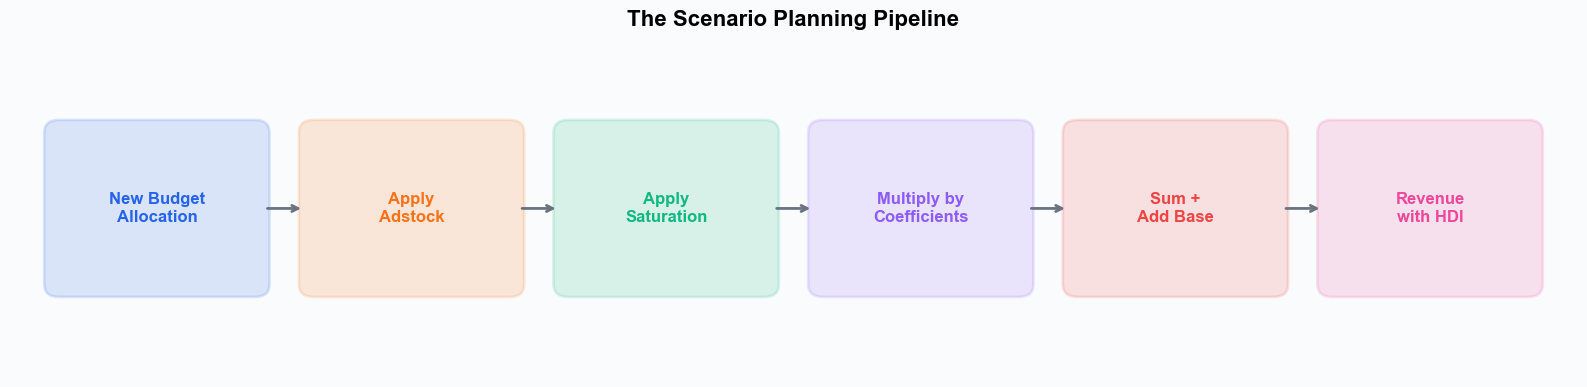

Pipeline diagram saved.


In [2]:
# --- Flow diagram: The Scenario Pipeline ---

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis('off')
ax.set_facecolor('#FAFBFC')

steps = [
    ('New Budget\nAllocation', '#2563EB'),
    ('Apply\nAdstock', '#F97316'),
    ('Apply\nSaturation', '#10B981'),
    ('Multiply by\nCoefficients', '#8B5CF6'),
    ('Sum +\nAdd Base', '#EF4444'),
    ('Revenue\nwith HDI', '#EC4899'),
]

box_w, box_h = 2.0, 1.8
y_center = 2.0
gap = 0.6

for i, (label, color) in enumerate(steps):
    x = 0.5 + i * (box_w + gap)
    box = FancyBboxPatch((x, y_center - box_h/2), box_w, box_h,
                         boxstyle='round,pad=0.15', facecolor=color, alpha=0.15,
                         edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x + box_w/2, y_center, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color=color)

    if i < len(steps) - 1:
        ax.annotate('', xy=(x + box_w + gap - 0.1, y_center),
                    xytext=(x + box_w + 0.1, y_center),
                    arrowprops=dict(arrowstyle='->', color='#6B7280', lw=2))

ax.set_title('The Scenario Planning Pipeline', fontsize=16, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('images/11_scenario_pipeline.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Pipeline diagram saved.')

---

## Fitting a Real PyMC-Marketing MMM

Instead of simulating posterior samples, we fit a **real Bayesian MMM** using PyMC-Marketing. This gives us genuine posterior distributions for all parameters â€” channel coefficients, adstock decay rates, and saturation alpha values â€” that we can then use for scenario planning.

We use `GeometricAdstock` (exponential carryover) and `TanhSaturation` (diminishing returns via `tanh(x / (scalar * alpha))`).

In [3]:
from pymc_marketing.mmm import MMM, GeometricAdstock, TanhSaturation

# Load data
df = pd.read_csv('data/sample_mmm_weekly.csv', parse_dates=['date'])

MEDIA_COLS = ['tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend']
CHANNEL_NAMES = ['TV', 'Facebook', 'Google Search', 'Radio', 'Print']

X = df[['date'] + MEDIA_COLS].copy()
y = df['revenue'].copy()

print(f'Data: {len(df)} weeks, {len(MEDIA_COLS)} channels')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Revenue: ${y.mean():,.0f}/week (mean), ${y.std():,.0f} (std)')
print(f'\nWeekly spend by channel:')
for col, name in zip(MEDIA_COLS, CHANNEL_NAMES):
    print(f'  {name:>15}: ${df[col].mean():>10,.0f}/week')

Data: 104 weeks, 5 channels
Date range: 2023-01-02 to 2024-12-23
Revenue: $441,919/week (mean), $25,075 (std)

Weekly spend by channel:
               TV: $    31,920/week
         Facebook: $    15,512/week
    Google Search: $    19,363/week
            Radio: $     3,598/week
            Print: $     2,205/week


In [4]:
# Build and fit the MMM
mmm = MMM(
    date_column='date',
    channel_columns=MEDIA_COLS,
    adstock=GeometricAdstock(l_max=8),
    saturation=TanhSaturation(),
    yearly_seasonality=2,
)

print('Fitting MMM with MCMC (chains=2, draws=500, tune=500)...')
print('This may take a few minutes on CPU.\n')

idata = mmm.fit(
    X=X, y=y,
    chains=2, draws=500, tune=500,
    cores=1,
    random_seed=42,
)

print('\nModel fitted successfully!')
print(f'Posterior shape: {idata.posterior.dims}')

Fitting MMM with MCMC (chains=2, draws=500, tune=500)...
This may take a few minutes on CPU.



Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, adstock_alpha, saturation_b, saturation_c, gamma_fourier, y_sigma]


Output()

...

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()


Model fitted successfully!
Posterior shape: FrozenMappingWarningOnValuesAccess({'chain': 2, 'draw': 500, 'channel': 5, 'fourier_mode': 4, 'date': 104})


In [5]:
# Quick model check: in-sample fit
y_pred = mmm.predict(X)
print(f'predict() returned shape: {y_pred.shape}')
r2 = 1 - np.sum((y.values - y_pred)**2) / np.sum((y.values - y.mean())**2)
print(f'In-sample R²: {r2:.3f}')
print(f'Mean observed:  ${y.mean():>12,.0f}')
print(f'Mean predicted: ${y_pred.mean():>12,.0f}')

Sampling: [y]


Output()

predict() returned shape: (104,)
In-sample R²: 0.521
Mean observed:  $     441,919
Mean predicted: $     441,897


---

## Helper: Scenario Prediction with the Fitted Model

We build a helper that takes a dictionary of weekly spend levels, constructs a new dataframe that matches the training period structure, and uses `mmm.sample_posterior_predictive()` to get full posterior predictions.

In [6]:
def make_scenario_df(spend_dict, reference_df):
    X_new = reference_df[['date']].copy()
    for col in MEDIA_COLS:
        X_new[col] = spend_dict.get(col, 0.0)
    return X_new


def predict_scenario(mmm, spend_dict, reference_df):
    """Run a scenario through the fitted model and return summary stats.

    Returns dict with:
      - samples: full posterior predictive (n_obs, n_samples)
      - weekly_mean: mean prediction per week
      - mean, hdi_lo, hdi_hi: summary stats of mean weekly revenue
      - annual: annualized revenue estimate
    """
    X_new = make_scenario_df(spend_dict, reference_df)

    pp = mmm.sample_posterior_predictive(
        X_new, extend_idata=False, combined=True
    )

    # pp is an xarray Dataset; extract the target variable
    # The variable name is the model output_var (typically 'y')
    var_name = mmm.output_var if hasattr(mmm, 'output_var') else 'y'
    if isinstance(pp, dict):
        arr = pp[var_name]
    elif hasattr(pp, 'data_vars'):
        # xarray Dataset
        arr = pp[var_name].values
    elif hasattr(pp, 'values'):
        arr = pp.values
    else:
        arr = np.array(pp)

    # Ensure 2D: (n_obs, n_samples)
    if arr.ndim == 1:
        n_obs = len(reference_df)
        n_samples = len(arr) // n_obs
        if n_samples > 0 and n_samples * n_obs == len(arr):
            arr = arr.reshape(n_obs, n_samples)
        else:
            arr = arr.reshape(1, -1)
    elif arr.ndim > 2:
        arr = arr.reshape(arr.shape[0], -1)

    weekly_mean = arr.mean(axis=1)
    sample_means = arr.mean(axis=0)

    return {
        'samples': arr,
        'weekly_mean': weekly_mean,
        'sample_means': sample_means,
        'mean': float(sample_means.mean()),
        'hdi_lo': float(np.percentile(sample_means, 3)),
        'hdi_hi': float(np.percentile(sample_means, 97)),
        'annual': float(weekly_mean.sum() * (52 / len(weekly_mean))),
    }


current_spend = {col: df[col].mean() for col in MEDIA_COLS}
total_weekly = sum(current_spend.values())
print('Current average weekly spend:')
for col, name in zip(MEDIA_COLS, CHANNEL_NAMES):
    print(f'  {name:>15}: ${current_spend[col]:>10,.0f}')
print(f'  {"TOTAL":>15}: ${total_weekly:>10,.0f}')

Current average weekly spend:
               TV: $    31,920
         Facebook: $    15,512
    Google Search: $    19,363
            Radio: $     3,598
            Print: $     2,205
            TOTAL: $    72,598


In [7]:
# --- Baseline prediction (current spend) ---
baseline = predict_scenario(mmm, current_spend, X)

print(f'Baseline predicted weekly revenue:')
print(f'  Mean:     ${baseline["mean"]:>12,.0f}')
print(f'  94% HDI:  ${baseline["hdi_lo"]:>12,.0f} — ${baseline["hdi_hi"]:>12,.0f}')
print(f'\nBaseline annual revenue (52 weeks):')
print(f'  ${baseline["annual"]:>12,.0f}')

Sampling: [y]


Output()

Baseline predicted weekly revenue:
  Mean:     $     446,725
  94% HDI:  $     441,173 — $     452,909

Baseline annual revenue (52 weeks):
  $  23,229,709


---

## Scenario 1: Increase Total Budget by 20%

The simplest scenario: scale all channels proportionally. Due to **saturation** (diminishing returns), a 20% budget increase will yield **less than 20% revenue increase**.

In [8]:
# Scale up all channels by 20%
scale_factor = 1.20
scenario1_spend = {col: spend * scale_factor for col, spend in current_spend.items()}
scenario1 = predict_scenario(mmm, scenario1_spend, X)

# Compare
revenue_lift = (scenario1['mean'] - baseline['mean']) / baseline['mean'] * 100

print(f'Scenario 1: +20% Budget (proportional)')
print(f'  Weekly spend: ${sum(scenario1_spend.values()):,.0f} (was ${total_weekly:,.0f})')
print(f'  Predicted weekly revenue: ${scenario1["mean"]:>12,.0f}')
print(f'  94% HDI: ${scenario1["hdi_lo"]:>12,.0f} — ${scenario1["hdi_hi"]:>12,.0f}')
print(f'\n  Revenue lift: {revenue_lift:+.1f}%')
print(f'  Budget elasticity: {revenue_lift/20:.2f} (< 1.0 confirms saturation)')

Sampling: [y]


Output()

Scenario 1: +20% Budget (proportional)
  Weekly spend: $87,117 (was $72,598)
  Predicted weekly revenue: $     450,104
  94% HDI: $     442,363 — $     457,990

  Revenue lift: +0.8%
  Budget elasticity: 0.04 (< 1.0 confirms saturation)


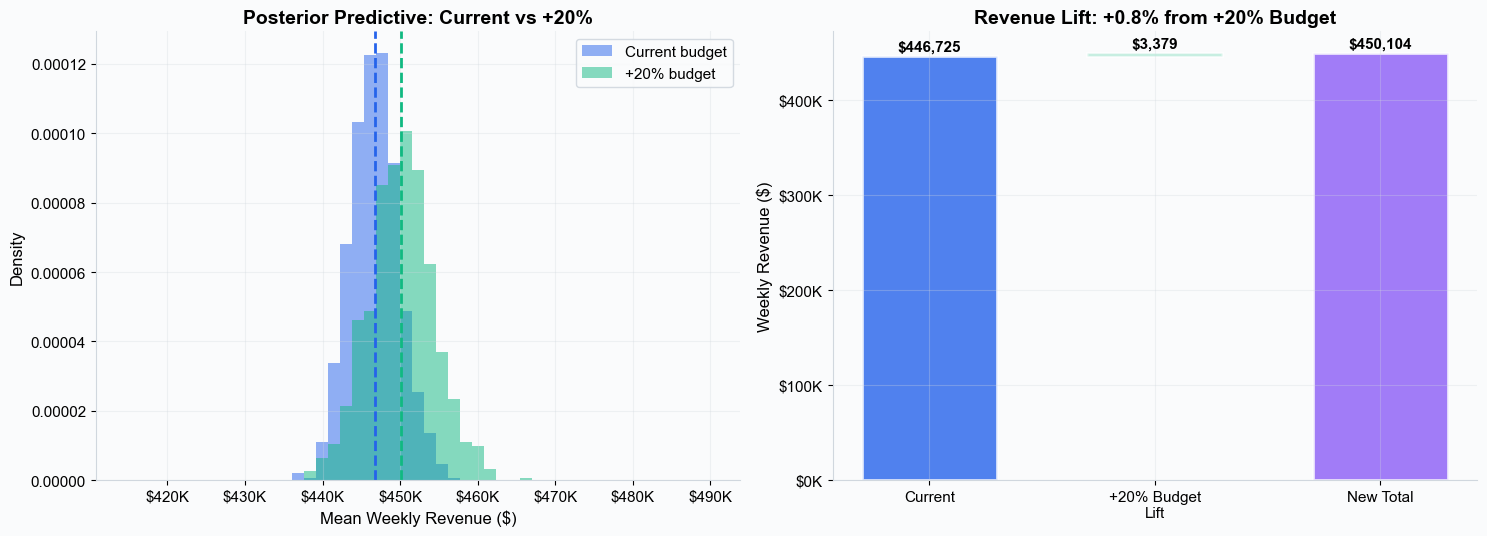

Scenario 1 chart saved.


In [9]:
# --- Visualization: Revenue comparison with uncertainty ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: Distribution comparison
bins = np.linspace(
    min(baseline['sample_means'].min(), scenario1['sample_means'].min()) * 0.95,
    max(baseline['sample_means'].max(), scenario1['sample_means'].max()) * 1.05,
    50
)
ax1.hist(baseline['sample_means'], bins=bins, alpha=0.5, color=COLORS[0],
         label='Current budget', density=True)
ax1.hist(scenario1['sample_means'], bins=bins, alpha=0.5, color=COLORS[2],
         label='+20% budget', density=True)
ax1.axvline(baseline['mean'], color=COLORS[0], linestyle='--', linewidth=2)
ax1.axvline(scenario1['mean'], color=COLORS[2], linestyle='--', linewidth=2)
ax1.set_xlabel('Mean Weekly Revenue ($)')
ax1.set_ylabel('Density')
ax1.set_title('Posterior Predictive: Current vs +20%')
ax1.legend()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Right: Waterfall of the lift
labels = ['Current', '+20% Budget\nLift', 'New Total']
values = [baseline['mean'], scenario1['mean'] - baseline['mean'], scenario1['mean']]
bottoms = [0, baseline['mean'], 0]
colors_wf = [COLORS[0], COLORS[2], COLORS[4]]

bars = ax2.bar(labels, values, bottom=bottoms, color=colors_wf, alpha=0.8,
               edgecolor='white', linewidth=2, width=0.6)
for bar, val, bot in zip(bars, values, bottoms):
    ax2.text(bar.get_x() + bar.get_width()/2, bot + val + baseline['mean']*0.005,
             f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_ylabel('Weekly Revenue ($)')
ax2.set_title(f'Revenue Lift: {revenue_lift:+.1f}% from +20% Budget')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('images/11_scenario1_budget_increase.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Scenario 1 chart saved.')

---

## Scenario 2: Shift 30% from TV to Digital

A common question: *"We spend a lot on TV. What if we moved some of that to Facebook and Google?"*

The total budget stays the same, but we reallocate 30% of TV spend. If TV is **more saturated** than digital channels, this reallocation can increase total revenue even without spending more.

In [10]:
# Shift 30% of TV to Facebook (15%) and Google (15%)
tv_shift = current_spend['tv_spend'] * 0.30
scenario2_spend = current_spend.copy()
scenario2_spend['tv_spend'] -= tv_shift
scenario2_spend['facebook_spend'] += tv_shift * 0.50
scenario2_spend['google_search_spend'] += tv_shift * 0.50

scenario2 = predict_scenario(mmm, scenario2_spend, X)
s2_lift = (scenario2['mean'] - baseline['mean']) / baseline['mean'] * 100

print(f'Scenario 2: Shift 30% of TV to Digital')
print(f'  TV:             ${scenario2_spend["tv_spend"]:>10,.0f} (was ${current_spend["tv_spend"]:>10,.0f})')
print(f'  Facebook:       ${scenario2_spend["facebook_spend"]:>10,.0f} (was ${current_spend["facebook_spend"]:>10,.0f})')
print(f'  Google Search:  ${scenario2_spend["google_search_spend"]:>10,.0f} (was ${current_spend["google_search_spend"]:>10,.0f})')
print(f'  Total spend:    ${sum(scenario2_spend.values()):>10,.0f} (unchanged)')
print(f'\n  Revenue lift: {s2_lift:+.1f}% (same budget, better allocation)')

Sampling: [y]


Output()

Scenario 2: Shift 30% of TV to Digital
  TV:             $    22,344 (was $    31,920)
  Facebook:       $    20,300 (was $    15,512)
  Google Search:  $    24,151 (was $    19,363)
  Total spend:    $    72,598 (unchanged)

  Revenue lift: +0.7% (same budget, better allocation)


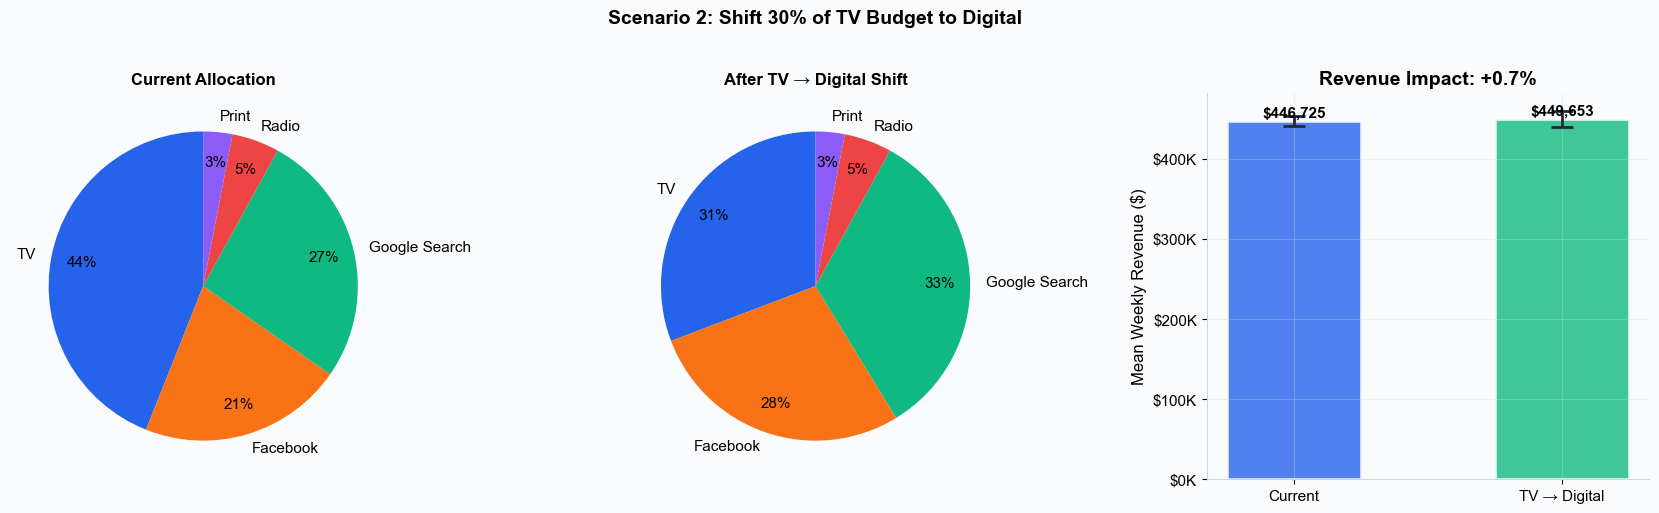

Scenario 2 chart saved.


In [11]:
# --- Visualization: Allocation pie charts + revenue comparison ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Pie chart: Current allocation
current_values = [current_spend[c] for c in MEDIA_COLS]
axes[0].pie(current_values, labels=CHANNEL_NAMES, colors=COLORS[:5], autopct='%1.0f%%',
           startangle=90, pctdistance=0.8)
axes[0].set_title('Current Allocation', fontsize=12)

# Pie chart: New allocation
new_values = [scenario2_spend[c] for c in MEDIA_COLS]
axes[1].pie(new_values, labels=CHANNEL_NAMES, colors=COLORS[:5], autopct='%1.0f%%',
           startangle=90, pctdistance=0.8)
axes[1].set_title('After TV → Digital Shift', fontsize=12)

# Bar chart: Revenue comparison
scenarios_s2 = ['Current', 'TV → Digital']
means = [baseline['mean'], scenario2['mean']]
errors_lo = [baseline['mean'] - baseline['hdi_lo'], scenario2['mean'] - scenario2['hdi_lo']]
errors_hi = [baseline['hdi_hi'] - baseline['mean'], scenario2['hdi_hi'] - scenario2['mean']]
bar_colors = [COLORS[0], COLORS[2]]

bars = axes[2].bar(scenarios_s2, means, color=bar_colors, alpha=0.8,
                   edgecolor='white', linewidth=2, width=0.5)
axes[2].errorbar(scenarios_s2, means, yerr=[errors_lo, errors_hi],
                fmt='none', color='#1F2937', capsize=8, capthick=2, linewidth=2)
for bar, val in zip(bars, means):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + max(errors_hi)*0.15,
                f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')
axes[2].set_ylabel('Mean Weekly Revenue ($)')
axes[2].set_title(f'Revenue Impact: {s2_lift:+.1f}%')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.suptitle('Scenario 2: Shift 30% of TV Budget to Digital', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/11_scenario2_reallocation.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Scenario 2 chart saved.')

---

## Scenario 3: Cut Spend by 50%

Budget cuts are inevitable. The question isn't whether to cut â€” it's **which channels to cut first**. Channels with the **flattest marginal response curves** (most saturated) should be cut first since you lose the least revenue per dollar.

In [12]:
# Compute marginal value by comparing with a small spend decrease per channel
delta = 1000  # $1000 decrease
marginal_values = {}

for col, name in zip(MEDIA_COLS, CHANNEL_NAMES):
    if current_spend[col] < delta:
        marginal_values[col] = 0.0
        continue

    # Predict with slightly less spend on this channel
    reduced = current_spend.copy()
    reduced[col] -= delta
    pred_reduced = predict_scenario(mmm, reduced, X)

    # Marginal value = revenue lost per $1000 cut
    marginal_values[col] = (baseline['mean'] - pred_reduced['mean']) / delta * 1000
    print(f'  {name:>15}: ${marginal_values[col]:>8,.2f} revenue per $1K spent')

# Sort channels by marginal value (lowest first = cut these first)
sorted_channels = sorted(marginal_values.keys(), key=lambda c: marginal_values[c])
print(f'\nCut order (least valuable first):')
for i, col in enumerate(sorted_channels, 1):
    name = col.replace('_spend', '').replace('_', ' ').title()
    print(f'  {i}. {name}: ${marginal_values[col]:,.2f}/$K')

Sampling: [y]


Output()

               TV: $   34.77 revenue per $1K spent


Sampling: [y]


Output()

...

Output()

            Radio: $   48.41 revenue per $1K spent


Sampling: [y]


Output()

            Print: $1,012.90 revenue per $1K spent

Cut order (least valuable first):
  1. Tv: $34.77/$K
  2. Radio: $48.41/$K
  3. Google Search: $109.64/$K
  4. Print: $1,012.90/$K
  5. Facebook: $1,013.99/$K


In [13]:
# Apply 50% total budget cut, prioritizing low-marginal channels
target_cut = sum(current_spend.values()) * 0.50
remaining_cut = target_cut

scenario3_spend = current_spend.copy()
cut_details = []

for col in sorted_channels:
    name = col.replace('_spend', '').replace('_', ' ').title()
    if remaining_cut <= 0:
        cut_details.append((name, 0, scenario3_spend[col]))
        continue

    max_cut = scenario3_spend[col]
    actual_cut = min(max_cut, remaining_cut)
    scenario3_spend[col] -= actual_cut
    remaining_cut -= actual_cut
    cut_details.append((name, actual_cut, scenario3_spend[col]))

scenario3 = predict_scenario(mmm, scenario3_spend, X)
s3_lift = (scenario3['mean'] - baseline['mean']) / baseline['mean'] * 100

print(f'Scenario 3: Smart 50% Budget Cut')
print(f'  Total cut: ${target_cut:,.0f}\n')
for name, cut, remaining in cut_details:
    if cut > 0:
        print(f'  {name:>15}: cut ${cut:>10,.0f} → ${remaining:>10,.0f} remaining')
    else:
        print(f'  {name:>15}: no cut         → ${remaining:>10,.0f} remaining')
print(f'\n  Revenue impact: {s3_lift:+.1f}% (less than 50% thanks to smart cutting)')

Sampling: [y]


Output()

Scenario 3: Smart 50% Budget Cut
  Total cut: $36,299

               Tv: cut $    31,920 → $         0 remaining
            Radio: cut $     3,598 → $         0 remaining
    Google Search: cut $       781 → $    18,582 remaining
            Print: no cut         → $     2,205 remaining
         Facebook: no cut         → $    15,512 remaining

  Revenue impact: -17.8% (less than 50% thanks to smart cutting)


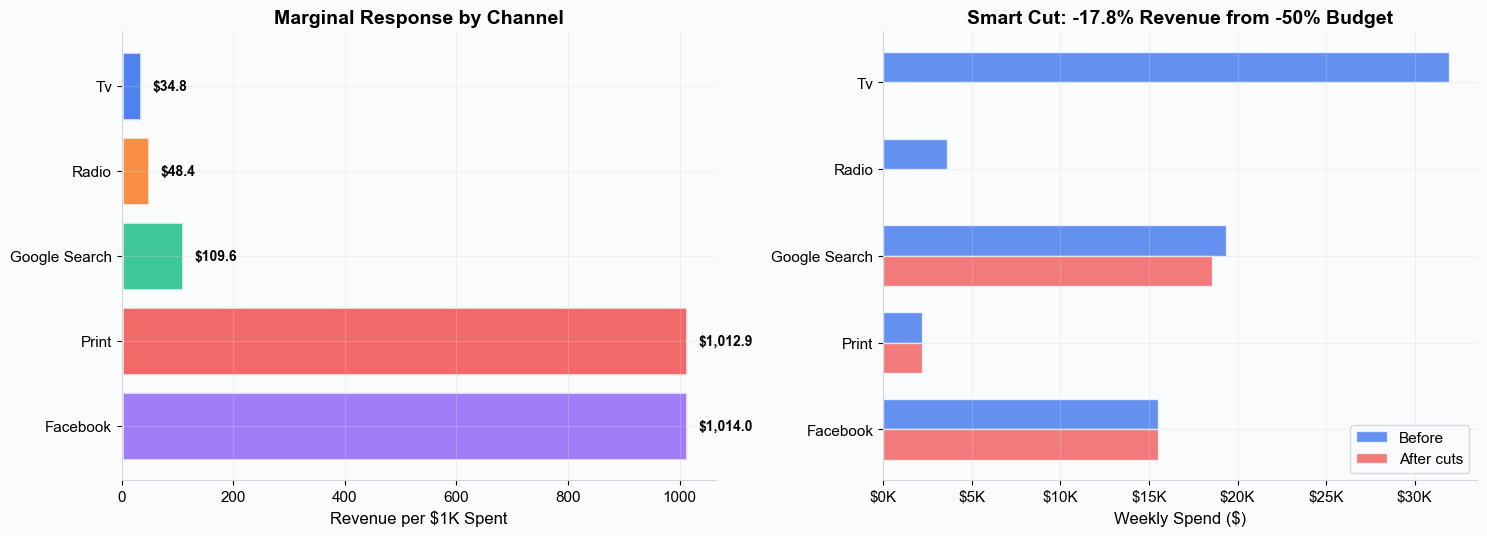

Scenario 3 chart saved.


In [14]:
# --- Visualization: Marginal values + cut waterfall ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: Marginal values by channel
sorted_names = [c.replace('_spend', '').replace('_', ' ').title() for c in sorted_channels]
sorted_vals = [marginal_values[c] for c in sorted_channels]
bar_colors_marginal = [COLORS[i % len(COLORS)] for i in range(len(sorted_channels))]

bars = ax1.barh(sorted_names, sorted_vals, color=bar_colors_marginal, alpha=0.8,
                edgecolor='white', linewidth=2)
for bar, val in zip(bars, sorted_vals):
    ax1.text(val + max(sorted_vals)*0.02, bar.get_y() + bar.get_height()/2,
             f'${val:,.1f}', va='center', fontweight='bold', fontsize=10)
ax1.set_xlabel('Revenue per $1K Spent')
ax1.set_title('Marginal Response by Channel')
ax1.invert_yaxis()

# Right: Before/after budget comparison
cut_channel_names = [d[0] for d in cut_details]
before_vals = [current_spend[c] for c in sorted_channels]
after_vals = [scenario3_spend[c] for c in sorted_channels]

x_pos = np.arange(len(cut_channel_names))
width = 0.35
ax2.barh(x_pos - width/2, before_vals, width, color=COLORS[0], alpha=0.7, label='Before', edgecolor='white')
ax2.barh(x_pos + width/2, after_vals, width, color=COLORS[3], alpha=0.7, label='After cuts', edgecolor='white')
ax2.set_yticks(x_pos)
ax2.set_yticklabels(cut_channel_names)
ax2.set_xlabel('Weekly Spend ($)')
ax2.set_title(f'Smart Cut: {s3_lift:+.1f}% Revenue from -50% Budget')
ax2.legend()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('images/11_scenario3_budget_cut.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Scenario 3 chart saved.')

---

## Scenario 4: Go Dark on TV

What happens if we stop TV advertising entirely? This scenario reveals two important insights:

1. **Immediate loss** â€” the direct revenue contribution of TV
2. **Carryover buffer** â€” adstock means the effect doesn't disappear instantly; past spend still carries over for several weeks

In [15]:
# Go dark on TV
scenario4_spend = current_spend.copy()
scenario4_spend['tv_spend'] = 0

scenario4 = predict_scenario(mmm, scenario4_spend, X)
s4_lift = (scenario4['mean'] - baseline['mean']) / baseline['mean'] * 100

print(f'Scenario 4: Go Dark on TV')
print(f'  TV spend: $0 (was ${current_spend["tv_spend"]:,.0f})')
print(f'  Predicted weekly revenue: ${scenario4["mean"]:>12,.0f}')
print(f'  94% HDI: ${scenario4["hdi_lo"]:>12,.0f} — ${scenario4["hdi_hi"]:>12,.0f}')
print(f'\n  Revenue impact: {s4_lift:+.1f}%')
print(f'  Annual revenue loss: ${(baseline["annual"] - scenario4["annual"]):>12,.0f}')

Sampling: [y]


Output()

Scenario 4: Go Dark on TV
  TV spend: $0 (was $31,920)
  Predicted weekly revenue: $     382,720
  94% HDI: $     248,706 — $     442,244

  Revenue impact: -14.3%
  Annual revenue loss: $   3,328,289


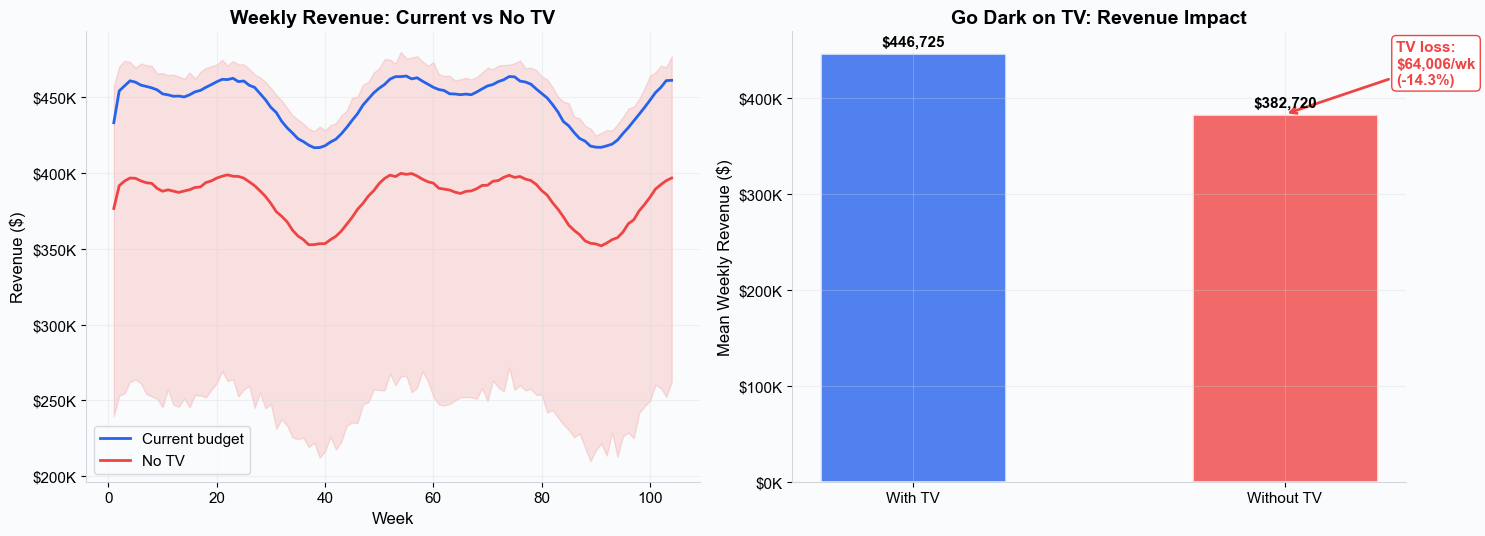

Scenario 4 chart saved.


In [16]:
# --- Visualization: Go dark impact ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: Weekly revenue trajectory (baseline vs go-dark)
weeks = np.arange(1, len(baseline['weekly_mean']) + 1)
ax1.plot(weeks, baseline['weekly_mean'], color=COLORS[0], linewidth=2, label='Current budget')
ax1.plot(weeks, scenario4['weekly_mean'], color=COLORS[3], linewidth=2, label='No TV')

# Uncertainty band for go-dark
s4_lo = np.percentile(scenario4['samples'], 3, axis=1)
s4_hi = np.percentile(scenario4['samples'], 97, axis=1)
ax1.fill_between(weeks, s4_lo, s4_hi, alpha=0.15, color=COLORS[3])

ax1.set_xlabel('Week')
ax1.set_ylabel('Revenue ($)')
ax1.set_title('Weekly Revenue: Current vs No TV')
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Right: Simple bar comparison
tv_loss = baseline['mean'] - scenario4['mean']
categories = ['With TV', 'Without TV']
vals = [baseline['mean'], scenario4['mean']]
ax2.bar(categories, vals, color=[COLORS[0], COLORS[3]], alpha=0.8,
        edgecolor='white', linewidth=2, width=0.5)

# Annotate the loss
mid_y = (baseline['mean'] + scenario4['mean']) / 2
ax2.annotate(f'TV loss:\n${tv_loss:,.0f}/wk\n({s4_lift:+.1f}%)',
             xy=(1, scenario4['mean']), xytext=(1.3, mid_y),
             fontsize=11, fontweight='bold', color=COLORS[3],
             arrowprops=dict(arrowstyle='->', color=COLORS[3], lw=2),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS[3]))

for i, val in enumerate(vals):
    ax2.text(i, val + baseline['mean']*0.01, f'${val:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_ylabel('Mean Weekly Revenue ($)')
ax2.set_title('Go Dark on TV: Revenue Impact')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('images/11_scenario4_go_dark.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Scenario 4 chart saved.')

---

## Building a Scenario Matrix

In practice, you don't evaluate one scenario at a time. You build a **matrix of scenarios** and compare them side-by-side. This makes it easy to present options to stakeholders.

In [17]:
# Define additional scenarios
scenarios_dict = {
    'Current': current_spend.copy(),
    '+20% Budget': {col: s * 1.20 for col, s in current_spend.items()},
    'TV → Digital': scenario2_spend.copy(),
    '-50% Smart Cut': scenario3_spend.copy(),
    'No TV': scenario4_spend.copy(),
    'Digital Only': {col: (current_spend['facebook_spend'] + current_spend['google_search_spend'])
                     if col in ['facebook_spend', 'google_search_spend'] else 0
                     for col in MEDIA_COLS},
}

# Use cached results where available, compute the rest
scenario_results = {
    'Current': baseline,
    '+20% Budget': scenario1,
    'TV → Digital': scenario2,
    '-50% Smart Cut': scenario3,
    'No TV': scenario4,
}

# Compute Digital Only
scenario_results['Digital Only'] = predict_scenario(mmm, scenarios_dict['Digital Only'], X)

# Summary table
print(f'{"Scenario":<18} {"Weekly Spend":>13} {"Weekly Rev":>12} {"94% HDI":>26} {"Lift":>8}')
print('-' * 82)
for name in scenarios_dict:
    res = scenario_results[name]
    spend = sum(scenarios_dict[name].values())
    lift = (res['mean'] - baseline['mean']) / baseline['mean'] * 100
    lift_str = f'{lift:+.1f}%' if name != 'Current' else '—'
    print(f'{name:<18} ${spend:>11,.0f} ${res["mean"]:>10,.0f}  '
          f'${res["hdi_lo"]:>10,.0f} — ${res["hdi_hi"]:>10,.0f} {lift_str:>8}')

Sampling: [y]


Output()

Scenario            Weekly Spend   Weekly Rev                    94% HDI     Lift
----------------------------------------------------------------------------------
Current            $     72,598 $   446,725  $   441,173 — $   452,909        —
+20% Budget        $     87,117 $   450,104  $   442,363 — $   457,990    +0.8%
TV → Digital       $     72,598 $   449,653  $   439,156 — $   459,332    +0.7%
-50% Smart Cut     $     36,299 $   367,387  $   234,639 — $   434,901   -17.8%
No TV              $     40,678 $   382,720  $   248,706 — $   442,244   -14.3%
Digital Only       $     69,749 $   361,281  $   231,815 — $   435,638   -19.1%


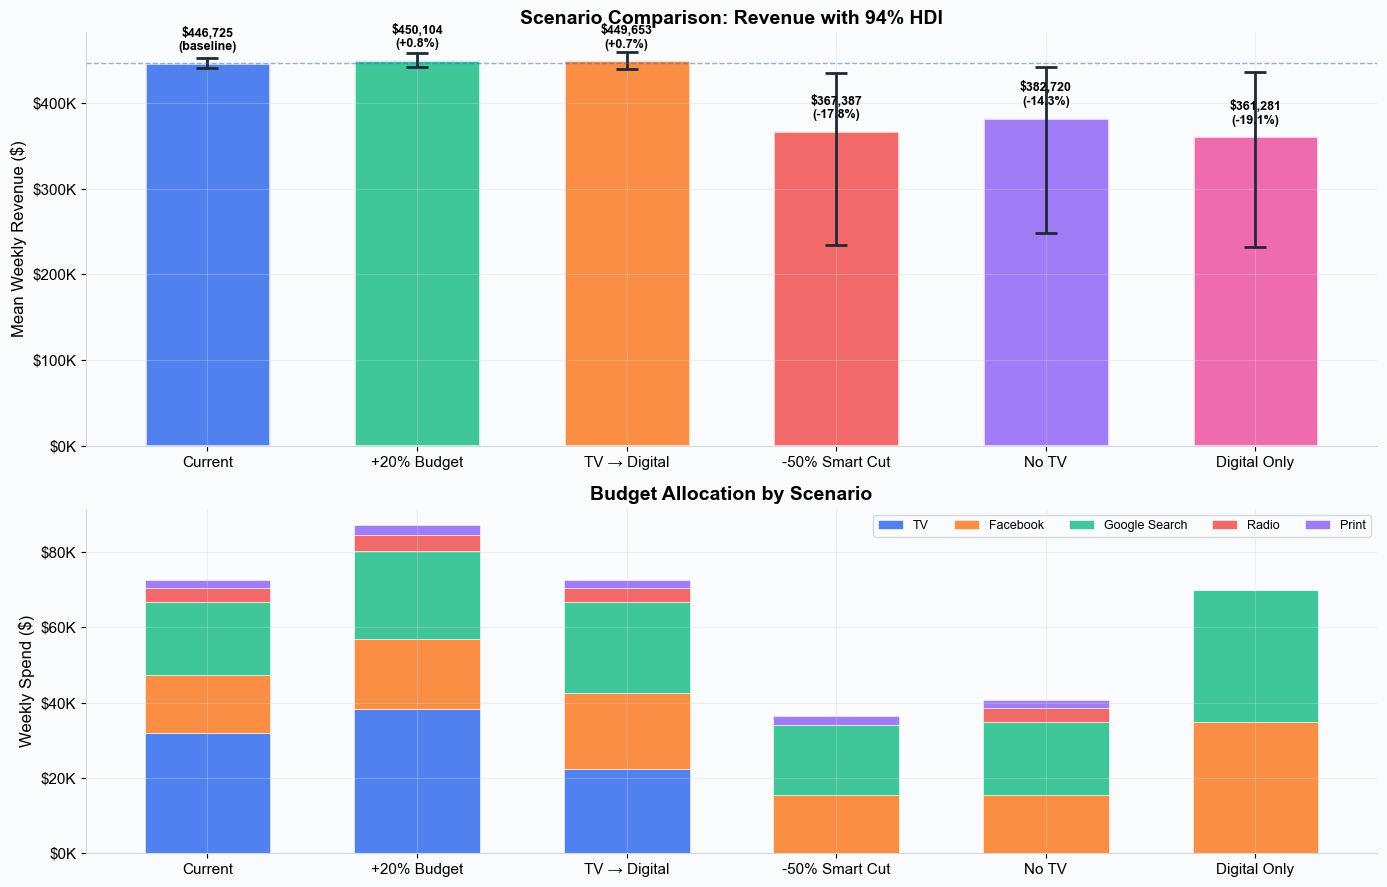

Scenario matrix chart saved.


In [18]:
# --- Visualization: Scenario comparison bar chart ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[1.2, 1])

scenario_names = list(scenarios_dict.keys())
revenues = [scenario_results[n]['mean'] for n in scenario_names]
lo_bounds = [scenario_results[n]['hdi_lo'] for n in scenario_names]
hi_bounds = [scenario_results[n]['hdi_hi'] for n in scenario_names]

# Top: Revenue comparison with error bars
x_pos = np.arange(len(scenario_names))
colors_bar = [COLORS[0], COLORS[2], COLORS[1], COLORS[3], COLORS[4], COLORS[5]]
errors_lo = [r - l for r, l in zip(revenues, lo_bounds)]
errors_hi = [h - r for r, h in zip(revenues, hi_bounds)]

bars = ax1.bar(x_pos, revenues, color=colors_bar, alpha=0.8,
               edgecolor='white', linewidth=2, width=0.6)
ax1.errorbar(x_pos, revenues, yerr=[errors_lo, errors_hi],
            fmt='none', color='#1F2937', capsize=8, capthick=2, linewidth=2)

for i, (bar, rev) in enumerate(zip(bars, revenues)):
    lift = (rev - baseline['mean']) / baseline['mean'] * 100
    label = f'${rev:,.0f}\n({lift:+.1f}%)' if i > 0 else f'${rev:,.0f}\n(baseline)'
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(errors_hi)*0.15,
             label, ha='center', va='bottom', fontweight='bold', fontsize=9)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(scenario_names)
ax1.set_ylabel('Mean Weekly Revenue ($)')
ax1.set_title('Scenario Comparison: Revenue with 94% HDI', fontsize=14)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax1.axhline(baseline['mean'], color=COLORS[0], linestyle='--', alpha=0.5, linewidth=1)

# Bottom: Spend allocation stacked bars
bottom = np.zeros(len(scenario_names))
for j, (col, name) in enumerate(zip(MEDIA_COLS, CHANNEL_NAMES)):
    values = [scenarios_dict[s][col] for s in scenario_names]
    ax2.bar(x_pos, values, bottom=bottom, color=COLORS[j], alpha=0.8,
            label=name, edgecolor='white', linewidth=0.5, width=0.6)
    bottom += np.array(values)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(scenario_names)
ax2.set_ylabel('Weekly Spend ($)')
ax2.set_title('Budget Allocation by Scenario')
ax2.legend(loc='upper right', ncol=5, fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('images/11_scenario_matrix.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Scenario matrix chart saved.')

---

## Uncertainty Quantification

Every scenario prediction comes with **uncertainty** â€” the 94% HDI (3%-97%) reflects how confident the model is. Wider HDI means less reliable prediction. Scenarios that push channels into untested spend ranges will have **wider uncertainty**.

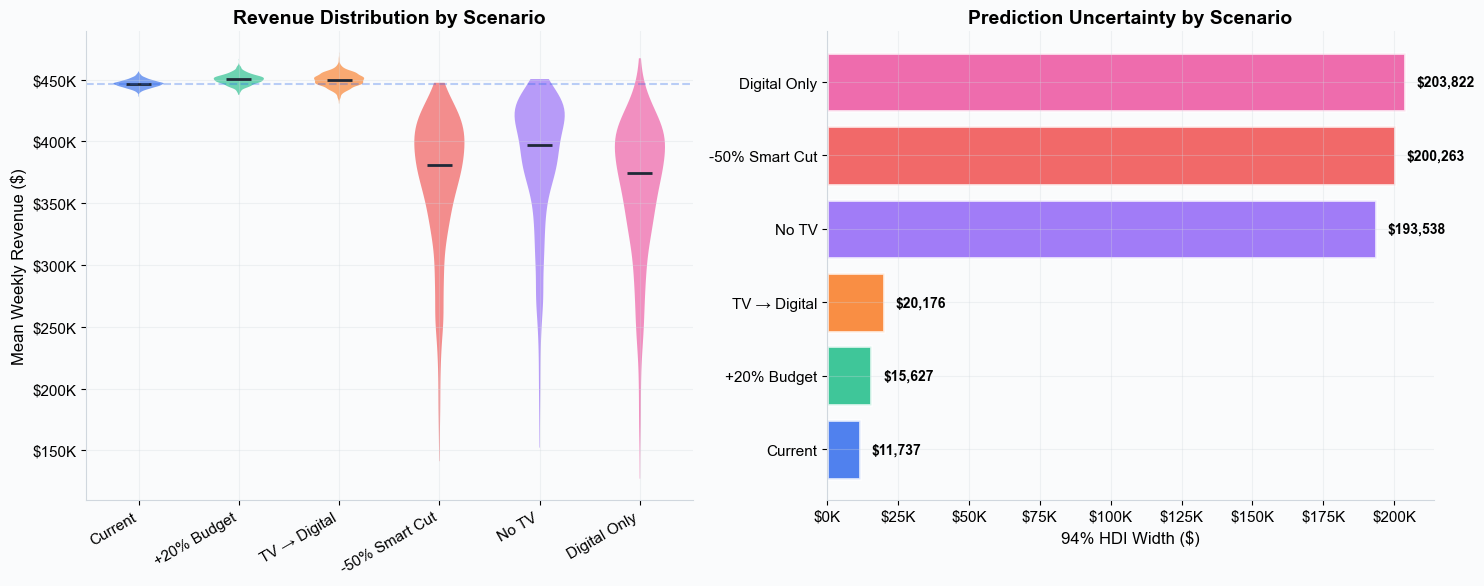

Uncertainty chart saved.


In [19]:
# --- Visualization: Uncertainty comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Violin plot of revenue distributions
scenario_data = [scenario_results[n]['sample_means'] for n in scenario_names]

parts = ax1.violinplot(scenario_data, positions=range(len(scenario_names)),
                       showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_bar[i])
    pc.set_alpha(0.6)
parts['cmedians'].set_color('#1F2937')
parts['cmedians'].set_linewidth(2)

ax1.set_xticks(range(len(scenario_names)))
ax1.set_xticklabels(scenario_names, rotation=30, ha='right')
ax1.set_ylabel('Mean Weekly Revenue ($)')
ax1.set_title('Revenue Distribution by Scenario')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax1.axhline(baseline['mean'], color=COLORS[0], linestyle='--', alpha=0.3)

# Right: HDI width comparison (uncertainty ranking)
hdi_widths = [(scenario_results[n]['hdi_hi'] - scenario_results[n]['hdi_lo']) for n in scenario_names]
sorted_idx = np.argsort(hdi_widths)

ax2.barh([scenario_names[i] for i in sorted_idx],
         [hdi_widths[i] for i in sorted_idx],
         color=[colors_bar[i] for i in sorted_idx], alpha=0.8,
         edgecolor='white', linewidth=2)
for i, idx in enumerate(sorted_idx):
    ax2.text(hdi_widths[idx] + max(hdi_widths)*0.02, i,
             f'${hdi_widths[idx]:,.0f}', va='center', fontweight='bold', fontsize=10)
ax2.set_xlabel('94% HDI Width ($)')
ax2.set_title('Prediction Uncertainty by Scenario')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('images/11_uncertainty.png', dpi=180, bbox_inches='tight',
            facecolor='#FAFBFC', edgecolor='none')
plt.show()
print('Uncertainty chart saved.')

---

## Key Takeaways

| Concept | What it means |
|---|---|
| **Scenario pipeline** | New budget â†’ adstock â†’ saturation â†’ coefficients â†’ revenue |
| **Proportional scale-up** | Saturation limits returns â€” +20% spend â‰  +20% revenue |
| **Reallocation wins** | Shifting from saturated to unsaturated channels improves total return at the same budget |
| **Smart cuts** | Cut the most-saturated channels first to minimize revenue loss |
| **Go-dark analysis** | Actual loss depends on carryover effects (adstock decay) |
| **Scenario matrix** | Compare all options side-by-side with uncertainty bands |
| **Uncertainty grows** | Scenarios far from observed data have wider HDI â€” the model honestly says "I'm less sure" |
| **Real model, real posteriors** | Using PyMC-Marketing's fitted MMM gives genuine Bayesian uncertainty, not simulated parameters |

### Next in this series

- **Notebook 12: Halo & Trademark Effects** â€” cross-channel spillover
- **Notebook 13: MMM-to-VAR Pipeline** â€” linking short-run and long-run effects

---

*Notebook 11 of the PyMC-Marketing MMM series. Uses PyMC-Marketing 0.19.2 with real MCMC inference.*